In [1]:
import tensorflow as tf

TRAIN_PATH = "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing"
TEST_PATH  = "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training"

2026-03-18 06:02:27.560286: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773813747.803183      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773813747.877198      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773813748.434159      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773813748.434211      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773813748.434217      55 computation_placer.cc:177] computation placer alr

In [2]:
train = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_PATH,
    image_size=(128,128),
    batch_size=32
)

Found 1600 files belonging to 4 classes.


2026-03-18 06:02:57.827128: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [3]:
test = tf.keras.preprocessing.image_dataset_from_directory(
    TEST_PATH,
    image_size=(128,128),
    batch_size=32
)

Found 5600 files belonging to 4 classes.


In [4]:
train = train.map(lambda x,y: (x/255.0, y))
test = test.map(lambda x,y: (x/255.0, y))

In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(4, activation='softmax')  
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
history = model.fit(train, validation_data=test, epochs=5)

loss, acc = model.evaluate(test)

print("Test Accuracy:", acc)

Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.3916 - loss: 1.2673 - val_accuracy: 0.6270 - val_loss: 0.9021
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.7035 - loss: 0.7231 - val_accuracy: 0.6854 - val_loss: 0.7406
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.7794 - loss: 0.5208 - val_accuracy: 0.7561 - val_loss: 0.6734
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - accuracy: 0.8741 - loss: 0.3670 - val_accuracy: 0.7536 - val_loss: 0.7476
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.9067 - loss: 0.2505 - val_accuracy: 0.7616 - val_loss: 0.7733
175/175 ━━━━━━━━━━━━━━━━━━━━ 28s 157ms/step - accuracy: 0.7677 - loss: 0.7657
Test Accuracy: 0.7616071701049805


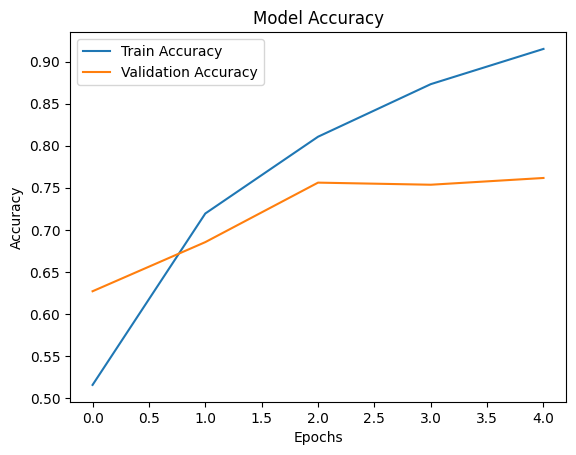

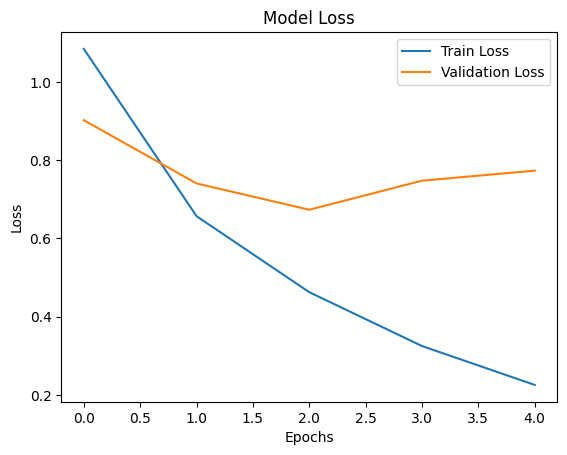

In [7]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [9]:

train = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_PATH,
    image_size=(128,128),
    batch_size=32
)

test = tf.keras.preprocessing.image_dataset_from_directory(
    TEST_PATH,
    image_size=(128,128),
    batch_size=32
)

class_names = train.class_names

train = train.map(lambda x,y: (x/255.0, y))
test = test.map(lambda x,y: (x/255.0, y))

Found 1600 files belonging to 4 classes.
Found 5600 files belonging to 4 classes.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step


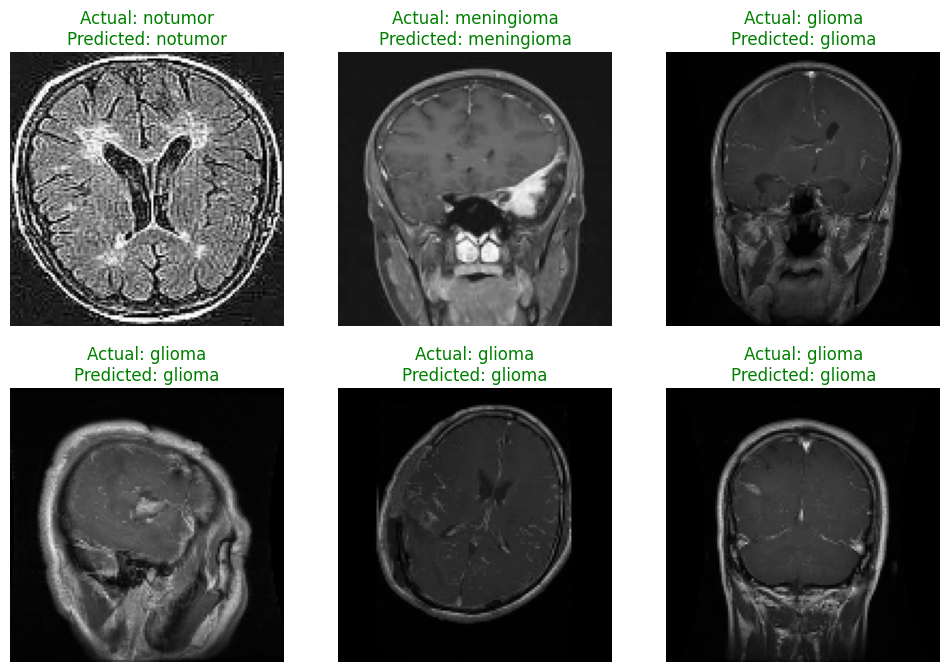

In [10]:
import matplotlib.pyplot as plt
import numpy as np

images, labels = next(iter(test))
predictions = model.predict(images)
predicted_labels = np.argmax(predictions, axis=1)

plt.figure(figsize=(12,8))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i].numpy())
    plt.axis("off")

    actual = class_names[labels[i]]
    predicted = class_names[predicted_labels[i]]

    color = "green" if actual == predicted else "red"

    plt.title(f"Actual: {actual}\nPredicted: {predicted}", color=color)

plt.show()